# Amazon Beauty — TIGER retrieval transformer

Trains the generative-retrieval transformer (SPEC §6–§7) on Amazon Beauty,
assuming the **RQ-VAE is already trained** (its `best.pt`, `*_items.csv`, and
`*_embeddings.npy` live under `rq-vae/outputs/`). End-to-end:

1. Preprocess Beauty 5-core reviews → leave-one-out `train/val/test.jsonl`
2. Run the trained RQ-VAE → `item_to_sid.json` / `sid_to_item.json`
3. Train the T5-style encoder–decoder (beam-decoded NDCG@10 on val every 5K steps, best ckpt saved)
4. Evaluate the best checkpoint on the **test** split → Recall@{5,10}, NDCG@{5,10}, invalid-ID rate (SPEC §9)

Assumes this project directory lives in Google Drive at `MyDrive/tiger/`, same as the RQ-VAE notebook.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import sys
from pathlib import Path

# Project root in Drive. The `retrieval` package imports as `from retrieval.x
# import ...`, so ROOT (not retrieval/) goes on sys.path and is the cwd.
ROOT = Path("/content/drive/MyDrive/tiger")
assert (ROOT / "retrieval" / "train.py").exists(), f"bad ROOT: {ROOT}"
assert (ROOT / "rq-vae" / "outputs" / "amazon_beauty_checkpoints" / "best.pt").exists(), \
    "RQ-VAE checkpoint missing — train the RQ-VAE first (amazon_beauty_experiments.ipynb)"

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Canonical paths used throughout the notebook.
DATA_DIR   = ROOT / "data"                      # item_to_sid.json + processed/*.jsonl land here
OUTPUT_DIR = ROOT / "outputs" / "tiger_beauty"  # checkpoints + metrics + val_curve
CONFIG     = ROOT / "retrieval" / "configs" / "beauty.yaml"
RQVAE_CKPT = ROOT / "rq-vae" / "outputs" / "amazon_beauty_checkpoints" / "best.pt"
RQVAE_ITEMS = ROOT / "rq-vae" / "outputs" / "amazon_beauty_items.csv"
RQVAE_EMB   = ROOT / "rq-vae" / "outputs" / "amazon_beauty_embeddings.npy"

# Colab has torch/numpy/pandas/matplotlib; pyyaml is the only thing sometimes missing.
!pip install -q pyyaml

In [3]:
import torch
print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0),
          "| bf16:", torch.cuda.is_bf16_supported())

torch 2.11.0+cu128 | cuda available: True
gpu: NVIDIA A100-SXM4-80GB | bf16: True


## 1. Preprocess Beauty reviews → leave-one-out sequences

Downloads the 5-core reviews dump, applies the iterative 5-core filter, sorts
each user's items by timestamp, and writes `train/val/test.jsonl` with the
sliding-window split (SPEC §3.3, §7.1). Re-run is cheap once the dump is cached
in Drive. Sanity-check the printed stats against the spec target
(users 22,363 / items 12,101 / mean 8.87 / median 6).

In [4]:
from scripts.preprocess_beauty import preprocess

reviews_path = DATA_DIR / "raw" / "reviews_Beauty_5.json.gz"
if (DATA_DIR / "processed" / "test.jsonl").exists():
    print("[skip] processed/*.jsonl already exist — delete them to rebuild")
else:
    preprocess(reviews_path, DATA_DIR / "processed", download_flag=False)

[prep] downloading http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Beauty_5.json.gz
[prep] wrote /content/drive/MyDrive/tiger/data/raw/reviews_Beauty_5.json.gz (44.8 MB)
[prep] parsed 198502 reviews
[prep] 5-core filter converged after 0 pass(es)
[prep] after 5-core: 198502 reviews
[prep] users=22363  items=12101  mean_seq_len=8.88  median_seq_len=6  (expected: 22,363 / 12,101 / 8.87 / 6)
[prep] wrote /content/drive/MyDrive/tiger/data/processed/train.jsonl (131413 rows)
[prep] wrote /content/drive/MyDrive/tiger/data/processed/val.jsonl (22363 rows)
[prep] wrote /content/drive/MyDrive/tiger/data/processed/test.jsonl (22363 rows)
[prep] done: train=131413  val=22363  test=22363


## 2. Build SID lookup tables from the trained RQ-VAE

Encodes the items appearing in the sequences through the frozen RQ-VAE to get
`(c0, c1, c2)`, assigns the collision-breaking `c3`, and writes
`item_to_sid.json` + `sid_to_item.json` into `data/` (SPEC §2). The RQ-VAE is
**not** modified here.

In [5]:
from scripts.build_sid_tables import build_tables

if (DATA_DIR / "sid_to_item.json").exists():
    print("[skip] item_to_sid.json / sid_to_item.json already exist — delete to rebuild")
else:
    build_tables(
        checkpoint=RQVAE_CKPT,
        items_csv=RQVAE_ITEMS,
        embeddings=RQVAE_EMB,
        sequences_dir=DATA_DIR / "processed",
        output_dir=DATA_DIR,
    )

[sid] device=cuda
[sid] loaded 259204 items, embeddings (259204, 768)
[sid] 12101 unique items across train/val/test sequences
[sid] filtered to 12101 items present in both
[sid] encoded to codes, shape=(12101, 3)
[sid] max collision bucket size = 3 (c3 capacity = 256)
[sid] wrote /content/drive/MyDrive/tiger/data/item_to_sid.json  (12101 items)
[sid] wrote /content/drive/MyDrive/tiger/data/sid_to_item.json
[sid] 12046 unique (c0,c1,c2) prefixes across 12101 items  (avg collisions/prefix = 1.00)


## 3. Train the TIGER transformer

Full spec run is **200K steps @ batch 256** (SPEC §7) — a few hours on an
A100/H100. The cell below loads `beauty.yaml` and lets you shrink the run for a
quick smoke test before committing the GPU hours. Set `QUICK_RUN = False` to
reproduce the paper numbers.

Validation (beam-decoded NDCG@10 / Recall@10 on the val split) runs every
`eval_every` steps; the best-by-NDCG@10 checkpoint is saved to
`outputs/tiger_beauty/checkpoints/best.pt`.

In [6]:
import yaml

with open(CONFIG) as f:
    cfg = yaml.safe_load(f)

# ---- Run-length knob -------------------------------------------------------
# QUICK_RUN trims steps + eval cadence so you can confirm the pipeline end-to-end
# in ~10-20 min. It will NOT reach the paper's metrics. Flip to False for the
# real 200K-step run.
QUICK_RUN = False
if QUICK_RUN:
    cfg["train"]["total_steps"]      = 4000
    cfg["train"]["warmup_steps"]     = 500
    cfg["train"]["eval_every"]       = 1000
    cfg["train"]["eval_max_batches"] = 20      # subsample val to keep beam-decode fast
    print("[cfg] QUICK_RUN — smoke test, will not match paper metrics")
else:
    print("[cfg] FULL run — 200K steps, expect several hours on an A100/H100")

print(yaml.safe_dump(cfg["train"], sort_keys=False))

[cfg] FULL run — 200K steps, expect several hours on an A100/H100
total_steps: 200000
batch_size: 256
warmup_steps: 10000
peak_lr: 0.01
beta1: 0.9
beta2: 0.999
weight_decay: 0.0
grad_clip: 1.0
label_smoothing: 0.0
seed: 42
log_every: 50
eval_every: 5000
eval_batch_size: 64
eval_beam_width: 50
eval_top_k: 10
eval_max_batches: null
num_workers: 2



In [7]:
from retrieval.train import train

train(cfg, data_dir=DATA_DIR, output_dir=OUTPUT_DIR)

[train] device=cuda  amp_dtype=torch.bfloat16
[train] train=131413  val=22363
[train] model params: 4,847,104
[train] step=     50/200000  loss=7.9187  lr=5.00e-05  step_per_s=9.7
[train] step=    100/200000  loss=7.6248  lr=1.00e-04  step_per_s=11.0
[train] step=    150/200000  loss=7.4154  lr=1.50e-04  step_per_s=11.6
[train] step=    200/200000  loss=7.3070  lr=2.00e-04  step_per_s=11.8
[train] step=    250/200000  loss=7.2361  lr=2.50e-04  step_per_s=12.0
[train] step=    300/200000  loss=7.0938  lr=3.00e-04  step_per_s=12.1
[train] step=    350/200000  loss=6.9060  lr=3.50e-04  step_per_s=12.2
[train] step=    400/200000  loss=6.7711  lr=4.00e-04  step_per_s=12.2
[train] step=    450/200000  loss=6.6544  lr=4.50e-04  step_per_s=12.3
[train] step=    500/200000  loss=6.5431  lr=5.00e-04  step_per_s=12.3
[train] step=    550/200000  loss=6.4114  lr=5.50e-04  step_per_s=12.3
[train] step=    600/200000  loss=6.2778  lr=6.00e-04  step_per_s=12.4
[train] step=    650/200000  loss=6.146

## 4. Evaluate the best checkpoint on the test split

Loads `best.pt`, rebuilds the model from its saved config, and runs beam search
(width 50, top-10 after filtering invalid SIDs) over the **test** split — the
same `validate()` used during training, pointed at `test.jsonl`. Reports
Recall@{5,10}, NDCG@{5,10}, and the invalid-ID rate (SPEC §8–§9).

In [8]:
import json
import torch
from torch.utils.data import DataLoader

from retrieval.dataset import TigerSequenceDataset, collate
from retrieval.model import TigerConfig, TigerTransformer
from retrieval.train import validate
from retrieval.vocab import PAD_ID

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Rebuild model from the checkpoint's own config ------------------------
ckpt = torch.load(OUTPUT_DIR / "checkpoints" / "best.pt", map_location=device, weights_only=False)
m = ckpt["config"]["model"]
model = TigerTransformer(TigerConfig(
    vocab_size=m["vocab_size"], d_model=m["d_model"], d_ff=m["d_ff"],
    num_heads=m["num_heads"], head_dim=m["head_dim"],
    num_encoder_layers=m["num_encoder_layers"], num_decoder_layers=m["num_decoder_layers"],
    dropout=m["dropout"], max_enc_len=m["max_enc_len"], max_dec_len=m["max_dec_len"],
    pad_id=PAD_ID, rel_num_buckets=m.get("rel_num_buckets", 32),
    rel_max_distance=m.get("rel_max_distance", 128),
    tie_embeddings=m.get("tie_embeddings", True),
    initializer_range=m.get("initializer_range", 0.02),
)).to(device)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"[eval] loaded best.pt from step {ckpt['step']} — val NDCG@10={ckpt['metrics']['ndcg@10']:.4f}")
print(f"[eval] model params: {model.num_params():,}")

# ---- Test split ------------------------------------------------------------
with open(DATA_DIR / "sid_to_item.json") as f:
    sid_to_item = json.load(f)
test_ds = TigerSequenceDataset(DATA_DIR / "processed" / "test.jsonl", DATA_DIR / "item_to_sid.json")
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=collate)
print(f"[eval] test examples: {len(test_ds)}")

test_metrics = validate(
    model, test_loader, sid_to_item, device=device,
    beam_width=cfg["train"].get("eval_beam_width", 50),
    top_k=cfg["train"].get("eval_top_k", 10),
    max_batches=None,   # full test set
)
print("[eval] test metrics:", json.dumps(test_metrics, indent=2))

[eval] loaded best.pt from step 25000 — val NDCG@10=0.0332
[eval] model params: 4,847,104
[eval] test examples: 22363
[eval] test metrics: {
  "recall@5": 0.02459419576979833,
  "ndcg@5": 0.016670465936484778,
  "recall@10": 0.03876939587711845,
  "ndcg@10": 0.021256222033945827,
  "invalid_rate": 0.0006752224656799176
}


## 5. Results vs. paper + validation curve

Compares the test metrics against the paper's reported Beauty numbers (SPEC §9;
±5% relative is a successful reproduction) and plots the NDCG@10 / Recall@10
validation curve from `metrics.json`.

In [9]:
import pandas as pd

PAPER = {"recall@5": 0.0454, "ndcg@5": 0.0321, "recall@10": 0.0648, "ndcg@10": 0.0384}
rows = []
for k in ["recall@5", "ndcg@5", "recall@10", "ndcg@10"]:
    ours, paper = test_metrics[k], PAPER[k]
    rel = (ours - paper) / paper * 100
    rows.append({
        "metric": k, "ours": round(ours, 4), "paper": paper,
        "rel_%": round(rel, 1), "within_5%": "✓" if abs(rel) <= 5 else "✗",
    })
results = pd.DataFrame(rows)
print(f"invalid-ID rate @10: {test_metrics['invalid_rate']:.4f}")
display(results)

invalid-ID rate @10: 0.0007


,metric,ours,paper,rel_%,within_5%
0,recall@5,0.0246,0.0454,-45.8,✗
1,ndcg@5,0.0167,0.0321,-48.1,✗
2,recall@10,0.0388,0.0648,-40.2,✗
3,ndcg@10,0.0213,0.0384,-44.6,✗


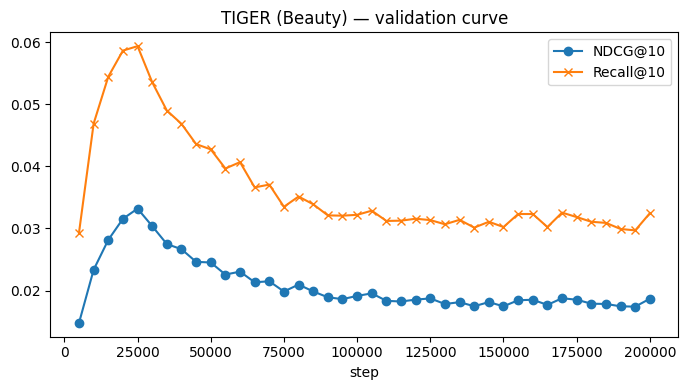

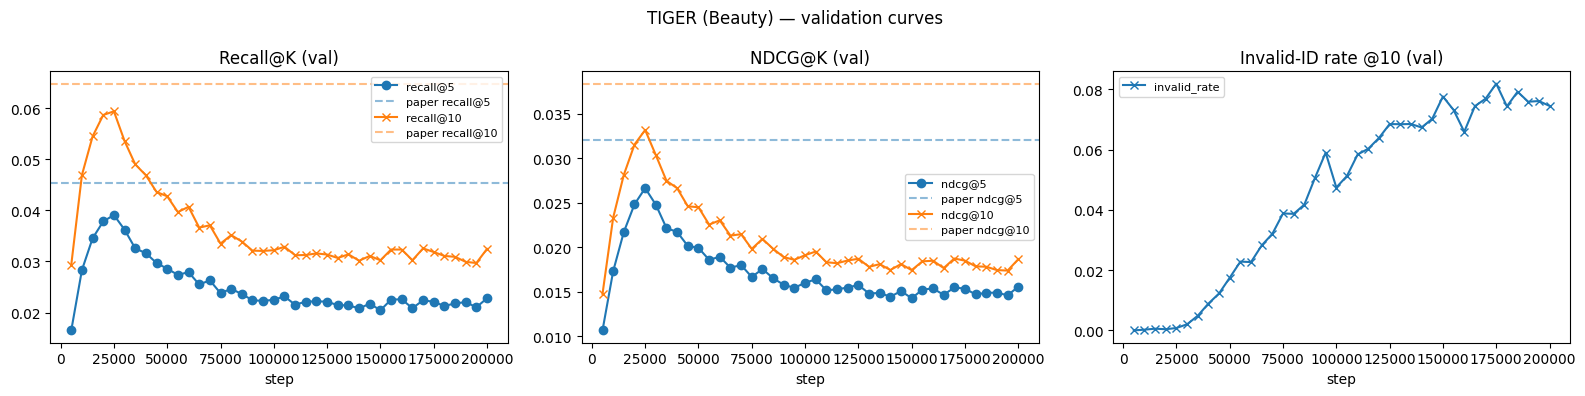

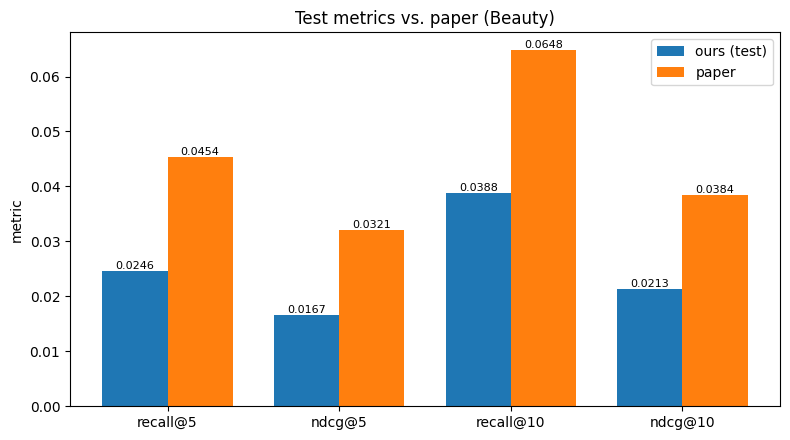

In [10]:
# train() switched matplotlib to the headless "Agg" backend (to save val_curve.png),
# which is process-global and kills inline rendering. Re-enable inline display.
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt

# Per-step eval history written during training. test_metrics / PAPER are
# already in memory from Step 4-5.
with open(OUTPUT_DIR / "metrics.json") as f:
    hist = json.load(f)["eval_history"]
steps = [h["step"] for h in hist]

# ---- Validation curves over training (Recall, NDCG, invalid-ID rate) ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
panels = [
    ("recall@5", "recall@10", "Recall@K (val)"),
    ("ndcg@5",   "ndcg@10",   "NDCG@K (val)"),
    (None,       "invalid_rate", "Invalid-ID rate @10 (val)"),
]
for ax, (m5, m10, title) in zip(axes, panels):
    if m5 is not None:
        ax.plot(steps, [h[m5] for h in hist], marker="o", label=m5)
        ax.axhline(PAPER[m5], ls="--", alpha=0.5, color="tab:blue", label=f"paper {m5}")
    ax.plot(steps, [h[m10] for h in hist], marker="x", label=m10)
    if m10 in PAPER:
        ax.axhline(PAPER[m10], ls="--", alpha=0.5, color="tab:orange", label=f"paper {m10}")
    ax.set_xlabel("step"); ax.set_title(title); ax.legend(fontsize=8)
fig.suptitle("TIGER (Beauty) — validation curves")
plt.tight_layout(); plt.show()

# ---- Final test metrics vs. paper (grouped bars) ----
keys = ["recall@5", "ndcg@5", "recall@10", "ndcg@10"]
ours  = [test_metrics[k] for k in keys]
paper = [PAPER[k] for k in keys]
x = np.arange(len(keys)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar(x - w/2, ours,  w, label="ours (test)")
b2 = ax.bar(x + w/2, paper, w, label="paper")
ax.bar_label(b1, fmt="%.4f", fontsize=8); ax.bar_label(b2, fmt="%.4f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(keys)
ax.set_ylabel("metric"); ax.set_title("Test metrics vs. paper (Beauty)")
ax.legend(); plt.tight_layout(); plt.show()